In [1]:
!pip install -q mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 67.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 1.3 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.0/814.0 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency re

In [2]:
import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

import mlflow
import dagshub

2026-03-04 11:53:13.747337: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772625193.970538      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772625194.033257      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772625194.547472      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772625194.547513      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772625194.547515      55 computation_placer.cc:177] computation placer alr

In [3]:
dagshub.init(
    repo_owner="Aryanupadhyay23",
    repo_name="Emotion-Detection-Deep-Learning",
    mlflow=True
)

mlflow.set_experiment("Emotion_ResNet50")

if mlflow.active_run():
    mlflow.end_run()

mlflow.start_run(run_name="ResNet50")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=e7ca4db0-590b-41e5-b3ea-aa8c0cc10396&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=2f9179414aa0a9d7bf587b06454855ace8554c92f559373ce4d9f997fc7bb266




Accessing as Aryanupadhyay23

Initialized MLflow to track repo "Aryanupadhyay23/Emotion-Detection-Deep-Learning"

Repository Aryanupadhyay23/Emotion-Detection-Deep-Learning initialized!

2026/03/04 11:54:00 INFO mlflow.tracking.fluent: Experiment with name 'Emotion_ResNet50' does not exist. Creating a new experiment.


<ActiveRun: >

In [4]:
DATASET_PATH = "/kaggle/input/datasets/sujaykapadnis/emotion-recognition-dataset/dataset"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 60
SEED = 42

In [5]:
mlflow.log_param("model", "ResNet50")
mlflow.log_param("image_size", IMG_SIZE)
mlflow.log_param("batch_size", BATCH_SIZE)
mlflow.log_param("epochs", EPOCHS)
mlflow.log_param("optimizer", "Adam")
mlflow.log_param("learning_rate", 3e-4)

0.0003

In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

Found 15453 files belonging to 6 classes.
Using 12363 files for training.


I0000 00:00:1772625255.594724      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772625255.601184      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 15453 files belonging to 6 classes.
Using 3090 files for validation.


In [7]:
train_ds = train_ds.map(
    lambda x,y:(x,tf.one_hot(y,num_classes)),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    lambda x,y:(x,tf.one_hot(y,num_classes)),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [9]:
labels=[]

for _,y in train_ds.unbatch():
    labels.append(np.argmax(y.numpy()))

labels=np.array(labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights=dict(enumerate(class_weights))

print(class_weights)

mlflow.log_dict(class_weights,"class_weights.json")

{0: np.float64(2.1264189886480906), 1: np.float64(1.9347417840375587), 2: np.float64(0.6845514950166113), 3: np.float64(0.6415006226650062), 4: np.float64(0.65936), 5: np.float64(2.0982688391038695)}


In [10]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [11]:
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE,IMG_SIZE,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
inputs = keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))

x = data_aug(inputs)

x = tf.keras.applications.resnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6)         │      1,542 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,121,990 (92.02 MB)

 Trainable params: 530,182 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [13]:
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss=loss_fn,
    metrics=["accuracy"]
)

In [14]:
callbacks=[

    keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3
    )

]

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/60


I0000 00:00:1772625305.938873     153 cuda_dnn.cc:529] Loaded cuDNN version 91002


387/387 ━━━━━━━━━━━━━━━━━━━━ 80s 176ms/step - accuracy: 0.3716 - loss: 1.9302 - val_accuracy: 0.5822 - val_loss: 1.2746 - learning_rate: 3.0000e-04
Epoch 2/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 79s 179ms/step - accuracy: 0.5166 - loss: 1.4026 - val_accuracy: 0.6019 - val_loss: 1.2418 - learning_rate: 3.0000e-04
Epoch 3/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 69s 177ms/step - accuracy: 0.5356 - loss: 1.2672 - val_accuracy: 0.6288 - val_loss: 1.1826 - learning_rate: 3.0000e-04
Epoch 4/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 68s 175ms/step - accuracy: 0.5702 - loss: 1.1816 - val_accuracy: 0.6181 - val_loss: 1.1815 - learning_rate: 3.0000e-04
Epoch 5/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 68s 175ms/step - accuracy: 0.5964 - loss: 1.1372 - val_accuracy: 0.6278 - val_loss: 1.1624 - learning_rate: 3.0000e-04
Epoch 6/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 69s 178ms/step - accuracy: 0.6100 - loss: 1.0930 - val_accuracy: 0.6466 - val_loss: 1.1410 - learning_rate: 3.0000e-04
Epoch 7/60
387/387 ━━━━━━━━━━━━━━━━━━━━ 69s 178ms/step - 

In [16]:
mlflow.log_metric("final_train_accuracy", history.history["accuracy"][-1])
mlflow.log_metric("final_val_accuracy", history.history["val_accuracy"][-1])
mlflow.log_metric("final_train_loss", history.history["loss"][-1])
mlflow.log_metric("final_val_loss", history.history["val_loss"][-1])

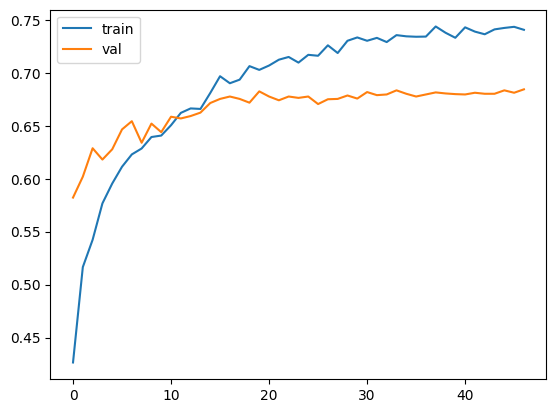

In [17]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["train","val"])

plt.savefig("training_curve.png")
mlflow.log_artifact("training_curve.png")

plt.show()

In [18]:
y_true=[]
y_pred=[]
y_prob=[]

for x,y in val_ds:

    preds=model.predict(x)

    y_true.extend(np.argmax(y.numpy(),axis=1))
    y_pred.extend(np.argmax(preds,axis=1))
    y_prob.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

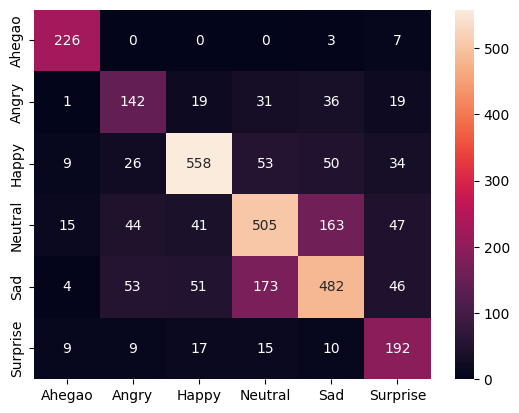

In [19]:
cm = confusion_matrix(y_true,y_pred)

sns.heatmap(cm,annot=True,fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.savefig("confusion_matrix.png")
mlflow.log_artifact("confusion_matrix.png")

plt.show()

In [20]:
report = classification_report(y_true,y_pred,target_names=class_names)

print(report)

with open("classification_report.txt","w") as f:
    f.write(report)

mlflow.log_artifact("classification_report.txt")

              precision    recall  f1-score   support

      Ahegao       0.86      0.96      0.90       236
       Angry       0.52      0.57      0.54       248
       Happy       0.81      0.76      0.79       730
     Neutral       0.65      0.62      0.63       815
         Sad       0.65      0.60      0.62       809
    Surprise       0.56      0.76      0.64       252

    accuracy                           0.68      3090
   macro avg       0.67      0.71      0.69      3090
weighted avg       0.69      0.68      0.68      3090



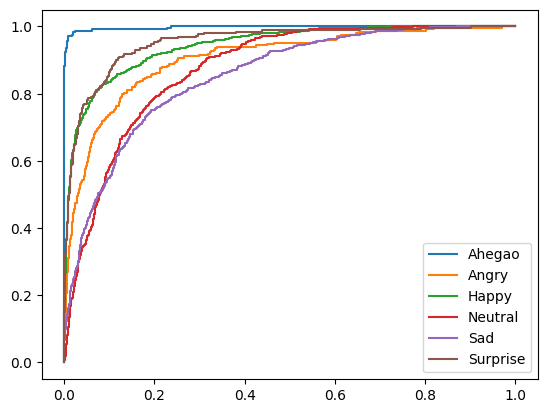

In [21]:
y_true_bin = label_binarize(y_true, classes=range(num_classes))
y_prob = np.array(y_prob)

for i in range(num_classes):

    fpr,tpr,_ = roc_curve(y_true_bin[:,i],y_prob[:,i])

    plt.plot(fpr,tpr,label=class_names[i])

plt.legend()

plt.savefig("roc_curve.png")
mlflow.log_artifact("roc_curve.png")

plt.show()

In [22]:
sample = next(iter(val_ds))[0]

times=[]

for _ in range(5):

    start=time.time()
    model.predict(sample)
    end=time.time()

    times.append((end-start)/len(sample))

latency=np.mean(times)

mlflow.log_metric("latency_per_image",latency)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


In [23]:
best_model = tf.keras.models.load_model("best_model.keras")

mlflow.tensorflow.log_model(
    best_model,
    artifact_path="resnet50_emotion_model"
)

2026/03/04 12:49:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 12:49:36 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [24]:
best_model = tf.keras.models.load_model("best_model.keras")

mlflow.tensorflow.log_model(
    best_model,
    artifact_path="resnet50_emotion_model"
)

2026/03/04 12:50:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 12:50:02 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [25]:
mlflow.end_run()

🏃 View run ResNet50 at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/2/runs/0021ff820bf248fbb076dc1690b8c293
🧪 View experiment at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/2
